# SOC Alert Prioritisation Framework
## MSc Cybersecurity Thesis

This notebook implements a transparent risk-scoring prototype for Wazuh alerts. 
It calculates a priority score between 0 and 100 and shows the resulting order 
for six controlled Atomic Red Team experiments. It does not evaluate whether 
attack alerts rank above benign alerts in a mixed operational queue.

The scoring formula is:

**Priority Score = (2 × L × (A + T)) / 4 × 100**

Where:
- L = Likelihood (derived from Wazuh alert severity level, scale 0.2 to 1.0)
- A = Asset Criticality (how important is the target machine, scale 0.10 to 1.00)
- T = ATT&CK Tactic Severity (how dangerous is this attack type, scale 0.10 to 1.00)

A score of 100 means maximum likelihood, targeting a critical asset, 
using the highest tactic value defined in the framework's mapping.

## Section 1: Scoring Engine

This section defines all the functions used to calculate the three factors.
Every alert in every dataset goes through these same functions.

Scoring engine loaded successfully.


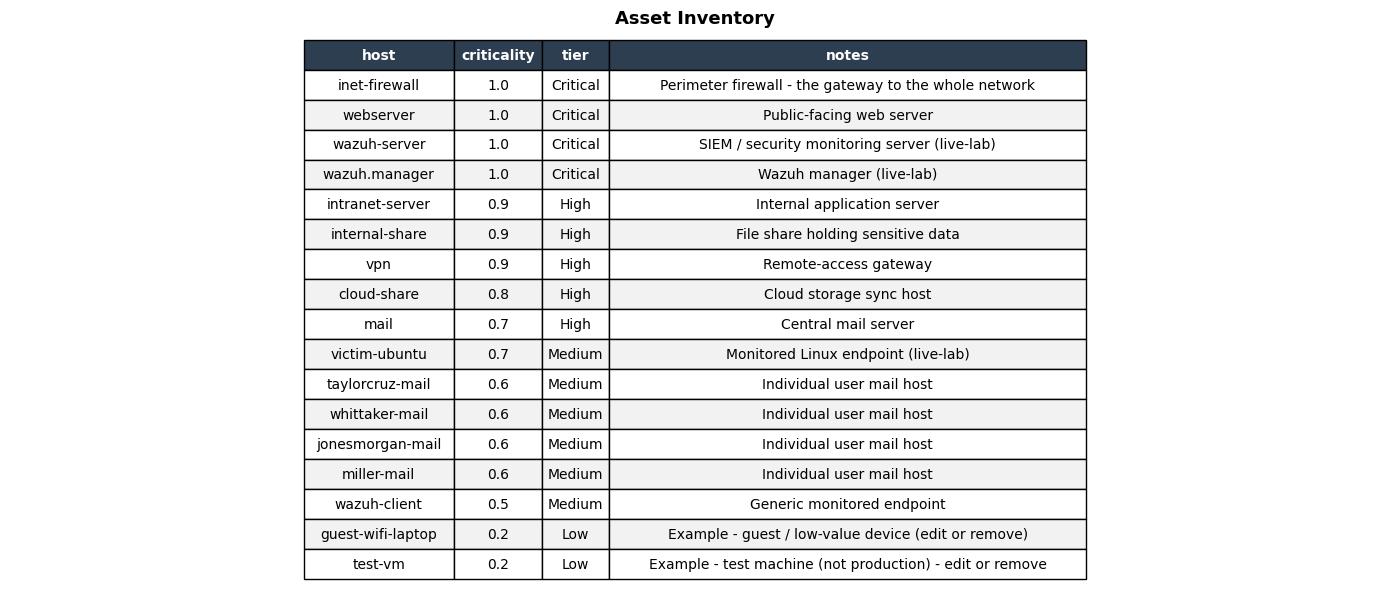

Saved asset_inventory_table.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
import re

# Load asset inventory
assets = pd.read_csv("asset_inventory.csv")
host_to_crit = dict(zip(assets["host"], assets["criticality"]))

# L: Wazuh rule level to likelihood score
def score_L(level):
    level = int(level)
    if level <= 3:   return 0.2
    elif level <= 5: return 0.4
    elif level <= 7: return 0.6
    elif level <= 9: return 0.8
    else:            return 1.0

# A: Asset criticality from inventory, default 0.1 if unknown host
def score_A(host):
    return host_to_crit.get(host, 0.10)

# T: ATT&CK tactic severity table
tactic_T = {
    "Reconnaissance": 0.30, "Resource Development": 0.30,
    "Initial Access": 0.40,
    "Execution": 0.50, "Persistence": 0.50, "Discovery": 0.50,
    # ATT&CK v19 (Apr 2026) split Defense Evasion into Stealth + Defense Impairment
    "Stealth": 0.60, "Defense Impairment": 0.60,
    "Defense Evasion": 0.60,  # legacy alias (pre-v19)
    "Privilege Escalation": 0.60,
    "Credential Access": 0.70,
    "Collection": 0.80, "Command and Control": 0.80,
    "Lateral Movement": 0.90,
    "Exfiltration": 0.95,
    "Impact": 1.00,
}
DEFAULT_T = 0.10

# Composite score normalised to a 0-100 scale, with 100 the theoretical maximum
def composite_score(L, A, T):
    return round((2 * L * (A + T)) / 4 * 100, 2)

# Priority band based on score
def band(s):
    if s >= 37.5:  return "CRITICAL"
    elif s >= 25.0: return "HIGH"
    elif s >= 12.5: return "MEDIUM"
    else:           return "LOW"

# CSV loader that handles Wazuh bracketed MITRE fields
def load_wazuh_csv(path):
    with open(
        path,
        encoding="utf-8-sig",
        errors="replace",
        newline=""
    ) as file:
        raw = list(csv.reader(file))

    header = raw[0]
    ncol = len(header)
    fixed = []

    for row in raw[1:]:

        if len(row) == ncol:
            fixed.append(row)

        elif len(row) > ncol:
            # Repair a comma inside rule.mitre.tactic
            extra_columns = len(row) - ncol
            tactic_end = 8 + extra_columns + 1

            repaired_row = (
                row[:8]
                + [",".join(row[8:tactic_end])]
                + row[tactic_end:]
            )

            fixed.append(repaired_row)

        else:
            # Add empty values to an incomplete row
            repaired_row = (
                row + [""] * (ncol - len(row))
            )

            fixed.append(repaired_row)

    dataframe = pd.DataFrame(
        fixed,
        columns=header
    )

    return dataframe

# Extract tactic from Wazuh alert (no ground truth used here)
def tactic_from_alert(row):
    raw = str(row.get("rule.mitre.tactic", "")).strip()
    if raw in ("", "nan", "[]"):
        return DEFAULT_T
    found = re.findall(r'([A-Za-z ]+)', raw)
    scores = [tactic_T.get(t.strip(), DEFAULT_T) for t in found if t.strip() in tactic_T]
    return max(scores) if scores else DEFAULT_T

print("Scoring engine loaded successfully.")

# Display asset inventory as a neat table
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

col_labels = list(assets.columns)
table_data = assets.values.tolist()

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Header row styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternating row colours
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        if i % 2 == 0:
            table[i, j].set_facecolor("#f2f2f2")
        else:
            table[i, j].set_facecolor("white")

plt.title("Asset Inventory", fontsize=13, fontweight="bold", pad=40)
table.auto_set_column_width(col=list(range(len(col_labels))))
plt.tight_layout()
plt.savefig("asset_inventory_table.png", dpi=150)
plt.show()
print("Saved asset_inventory_table.png")

## Section 3: Atomic Red Team Experiments

Six controlled Atomic Red Team tests were executed one at a time on the victim machine. Each test represented a different MITRE ATT&CK tactic. Each attack represents a different stage of the kill chain.

The framework scores each experiment two ways:

1. Using the intended Atomic Red Team tactic provides a controlled
   sensitivity comparison showing how the score changes when ATT&CK
   context is available.
2. Using Wazuh native detection only: shows Wazuh-only observed performance in this homelab, where Wazuh may not classify the tactic correctly.

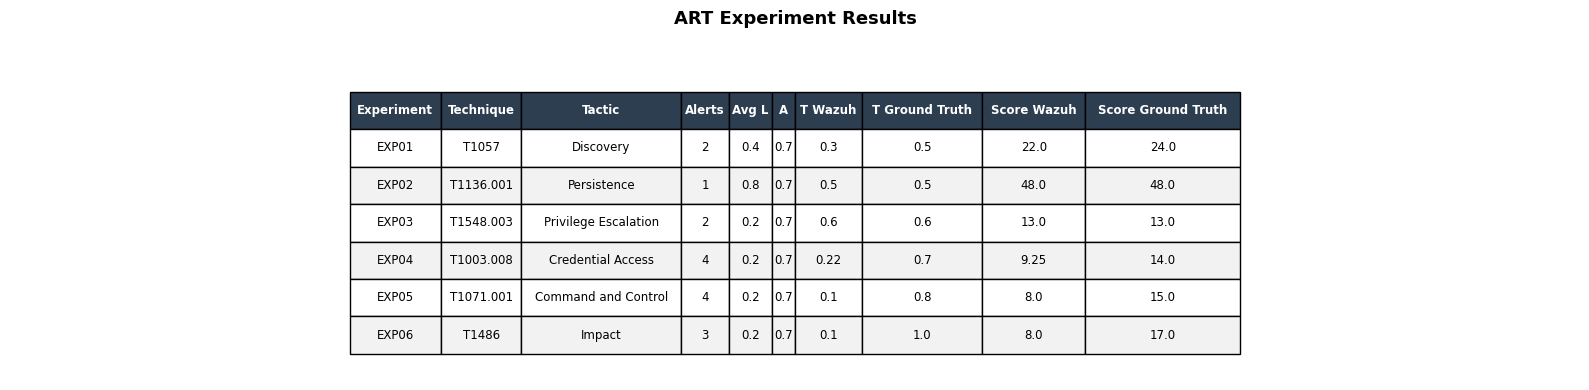

Saved art_results_table.png and master_results.csv


In [2]:
exp_files = {
    "EXP01": ("EXP01.csv",     "Discovery",           "T1057"),
    "EXP02": ("EXP02.csv",    "Persistence",         "T1136.001"),
    "EXP03": ("EXP03.csv", "Privilege Escalation", "T1548.003"),
    "EXP04": ("EXP04new.csv", "Credential Access",   "T1003.008"),
    "EXP05": ("EXP05.csv",    "Command and Control", "T1071.001"),
    "EXP06": ("EXP06.csv",    "Impact",              "T1486"),
}

results = []

for exp, (path, gt_tactic, technique) in exp_files.items():
    df = load_wazuh_csv(path)
    df["L"] = df["rule.level"].apply(score_L)
    df["A"] = df["agent.name"].apply(score_A)
    df["T_wazuh"] = df.apply(tactic_from_alert, axis=1)
    df["T_gt"] = tactic_T.get(gt_tactic, DEFAULT_T)
    df["score_wazuh"] = df.apply(lambda r: composite_score(r["L"], r["A"], r["T_wazuh"]), axis=1)
    df["score_gt"] = df.apply(lambda r: composite_score(r["L"], r["A"], r["T_gt"]), axis=1)

    results.append({
        "Experiment": exp,
        "Technique": technique,
        "Tactic": gt_tactic,
        "Alerts": len(df),
        "Avg L": round(df["L"].mean(), 2),
        "A": round(df["A"].iloc[0], 2),
        "T Wazuh": round(df["T_wazuh"].mean(), 2),
        "T Ground Truth": round(df["T_gt"].iloc[0], 2),
        "Score Wazuh": round(df["score_wazuh"].mean(), 2),
        "Score Ground Truth": round(df["score_gt"].mean(), 2),
    })

master = pd.DataFrame(results)

# Display as neat table
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")
table = ax.table(
    cellText=master.values.tolist(),
    colLabels=master.columns.tolist(),
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 2.2)
table.auto_set_column_width(col=list(range(len(master.columns))))

for j in range(len(master.columns)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(results) + 1):
    for j in range(len(master.columns)):
        table[i, j].set_facecolor("#f2f2f2" if i % 2 == 0 else "white")

ax.set_title("ART Experiment Results", fontsize=13, fontweight="bold", pad=30)
plt.tight_layout()
plt.savefig("art_results_table.png", dpi=150, bbox_inches="tight")
plt.show()

master.to_csv("master_results.csv", index=False)
print("Saved art_results_table.png and master_results.csv")

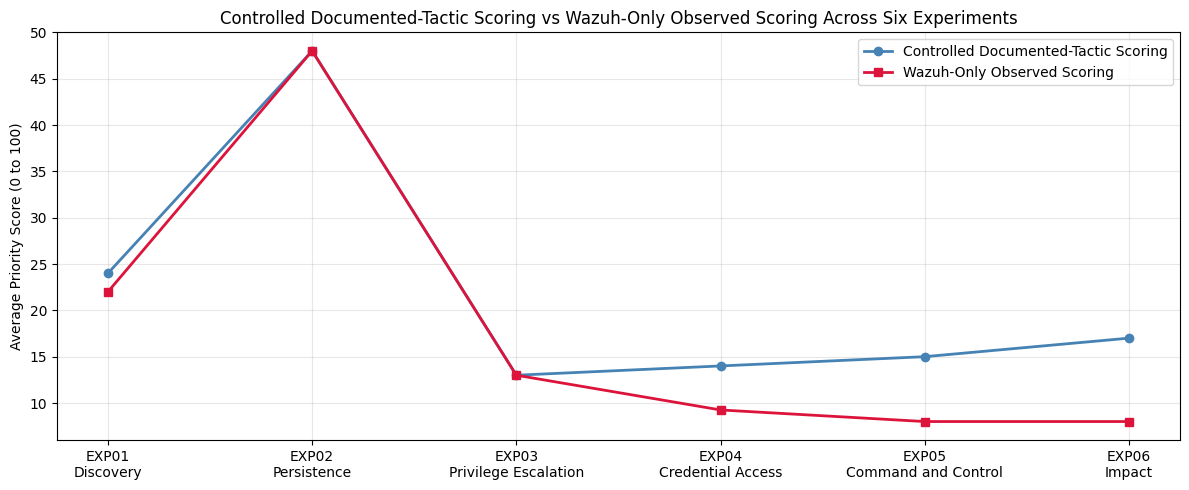

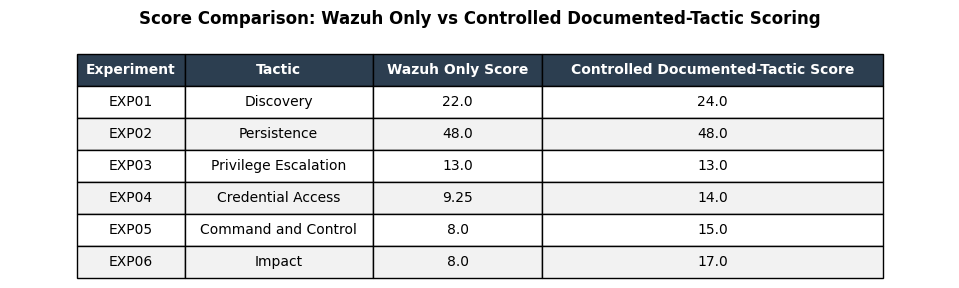

Saved demo_vs_eval.png and score_comparison_table.png


In [13]:
# Visual: Ground truth vs Wazuh only scores across experiments
labels = [f"{r['Experiment']}\n{r['Tactic']}" for _, r in master.iterrows()]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(labels, master["Score Ground Truth"], marker="o", color="steelblue",
        linewidth=2, label="Controlled Documented-Tactic Scoring")
ax.plot(labels, master["Score Wazuh"], marker="s", color="crimson",
        linewidth=2, label="Wazuh-Only Observed Scoring")

ax.set_ylabel("Average Priority Score (0 to 100)")
ax.set_title("Controlled Documented-Tactic Scoring vs Wazuh-Only Observed Scoring Across Six Experiments")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("demo_vs_eval.png", dpi=150, bbox_inches="tight")
plt.show()

# Also display scores as a neat table
compare = master[["Experiment", "Tactic", "Score Wazuh", "Score Ground Truth"]].copy()

fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.axis("off")
table = ax2.table(
    cellText=compare.values.tolist(),
    colLabels=["Experiment", "Tactic", "Wazuh Only Score", "Controlled Documented-Tactic Score"],
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)
table.auto_set_column_width(col=list(range(4)))

for j in range(4):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(compare) + 1):
    for j in range(4):
        table[i, j].set_facecolor("#f2f2f2" if i % 2 == 0 else "white")

ax2.set_title("Score Comparison: Wazuh Only vs Controlled Documented-Tactic Scoring",
              fontsize=12, fontweight="bold", pad=30)
plt.tight_layout()
plt.savefig("score_comparison_table.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved demo_vs_eval.png and score_comparison_table.png")

## Section 4: ART Experiment Alert Ranking

This section ranks alerts from the six Atomic Red Team experiments using 
Wazuh-only scoring. This is not a mixed operational queue it contains 
only ART attack alerts scored without ground truth tactic information. 
It demonstrates how the framework orders alerts across different kill-chain 
stages when deployed against controlled attack scenarios. Because this queue contains only attack-related experiment alerts and no benign comparison alerts, it demonstrates scoring behaviour and detection gaps rather than measuring attack-versus-benign ranking performanc .

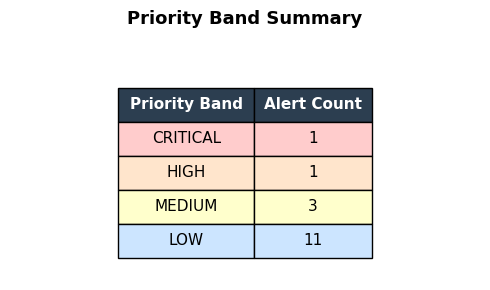

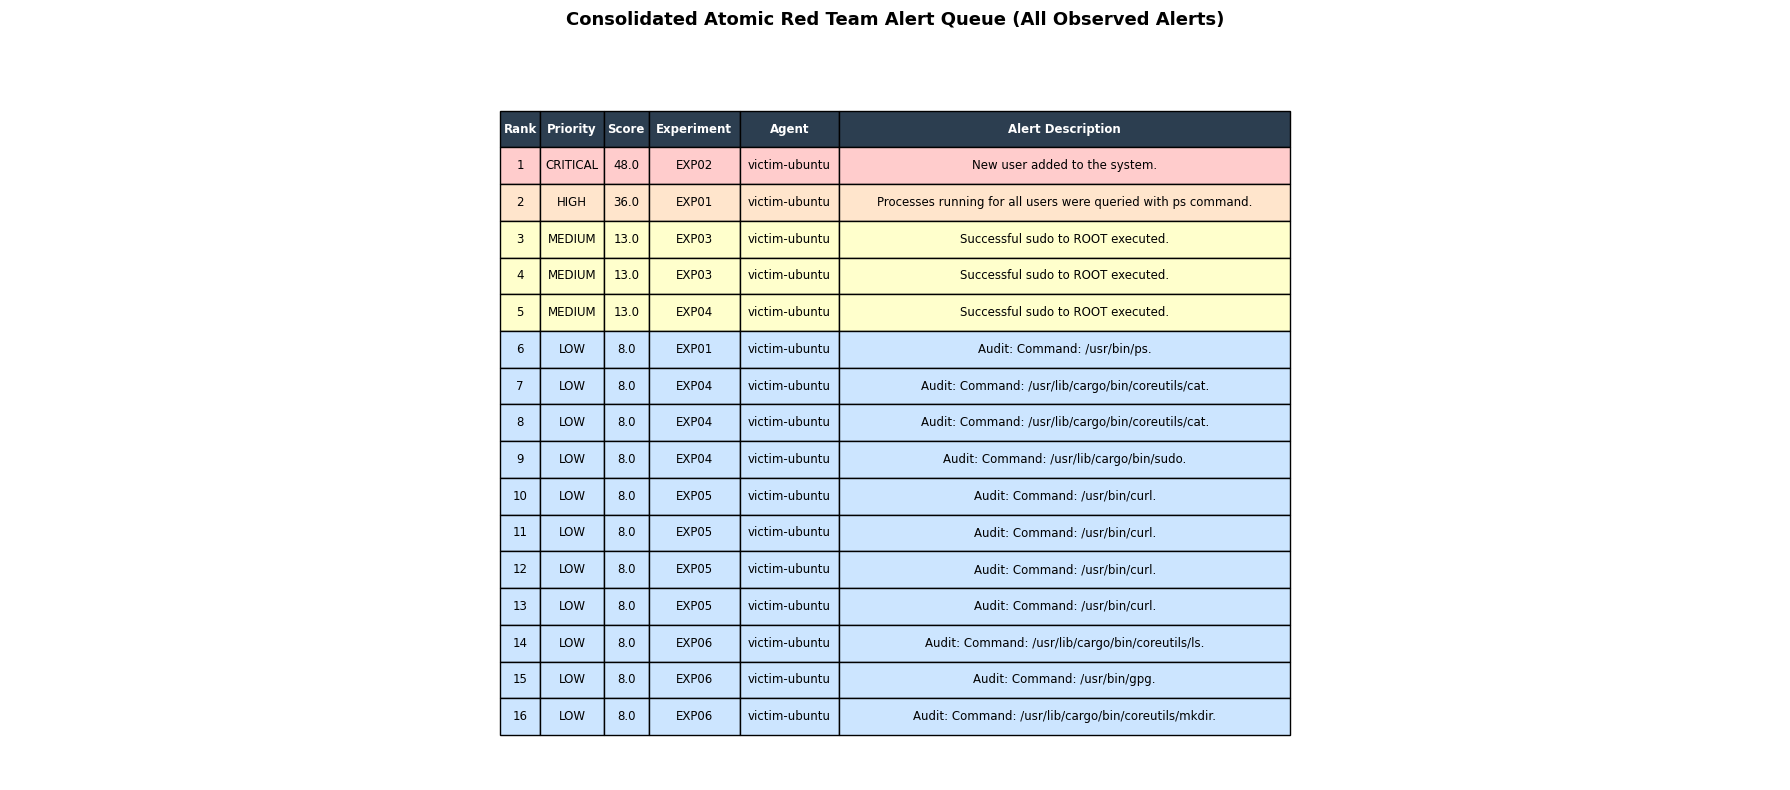

Saved priority_band_summary.png, final_soc_queue_table.png and final_soc_queue.csv


In [4]:
# Final queue: all experiments, all alerts, Wazuh only scoring
all_alerts = []

for exp, (path, gt_tactic, technique) in exp_files.items():
    df = load_wazuh_csv(path)
    df["L"] = df["rule.level"].apply(score_L)
    df["A"] = df["agent.name"].apply(score_A)
    df["T"] = df.apply(tactic_from_alert, axis=1)
    df["score"] = df.apply(lambda r: composite_score(r["L"], r["A"], r["T"]), axis=1)
    df["priority"] = df["score"].apply(band)
    df["experiment"] = exp
    all_alerts.append(df[["experiment", "agent.name",
                       "rule.level", "L", "A", "T", "score", "priority", "rule.description"]])

queue = pd.concat(all_alerts, ignore_index=True)
queue = queue.sort_values("score", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

band_colors = {"CRITICAL": "#ffcccc", "HIGH": "#ffe5cc", "MEDIUM": "#ffffcc", "LOW": "#cce5ff"}

# Priority band summary
band_summary = queue["priority"].value_counts().reindex(["CRITICAL", "HIGH", "MEDIUM", "LOW"]).fillna(0).astype(int)
summary_data = [[p, str(c)] for p, c in band_summary.items()]

fig1, ax1 = plt.subplots(figsize=(5, 3))
ax1.axis("off")
t1 = ax1.table(cellText=summary_data, colLabels=["Priority Band", "Alert Count"],
               loc="center", cellLoc="center")
t1.auto_set_font_size(False)
t1.set_fontsize(11)
t1.scale(1, 2.2)
t1.auto_set_column_width(col=[0, 1])
for j in range(2):
    t1[0, j].set_facecolor("#2c3e50")
    t1[0, j].set_text_props(color="white", fontweight="bold")
for i, (p, _) in enumerate(summary_data, start=1):
    for j in range(2):
        t1[i, j].set_facecolor(band_colors.get(p, "white"))
ax1.set_title("Priority Band Summary", fontsize=13, fontweight="bold", pad=30)
plt.tight_layout()
plt.savefig("priority_band_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 20 alerts table
top20 = queue[["rank", "priority", "score", "experiment",
               "agent.name", "rule.description"]].copy()
top20.columns = ["Rank", "Priority", "Score", "Experiment", "Agent", "Alert Description"]

fig2, ax2 = plt.subplots(figsize=(18, 8))
ax2.axis("off")
t2 = ax2.table(cellText=top20.values.tolist(),
               colLabels=top20.columns.tolist(),
               loc="center", cellLoc="center")
t2.auto_set_font_size(False)
t2.set_fontsize(8.5)
t2.scale(1, 1.9)
t2.auto_set_column_width(col=list(range(len(top20.columns))))
for j in range(len(top20.columns)):
    t2[0, j].set_facecolor("#2c3e50")
    t2[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(top20) + 1):
    priority = top20.iloc[i-1]["Priority"]
    color = band_colors.get(priority, "white")
    for j in range(len(top20.columns)):
        t2[i, j].set_facecolor(color)
ax2.set_title("Consolidated Atomic Red Team Alert Queue (All Observed Alerts)",
              fontsize=13, fontweight="bold", pad=30)
plt.tight_layout()
plt.savefig("final_soc_queue_table.png", dpi=150, bbox_inches="tight")
plt.show()

queue.to_csv("final_soc_queue.csv", index=False)
print("Saved priority_band_summary.png, final_soc_queue_table.png and final_soc_queue.csv")

Under ground-truth tactic scoring, EXP05 and EXP06 receive higher scores than under
Wazuh-only scoring, but they still remain below EXP02 because their Wazuh likelihood
value remains low.

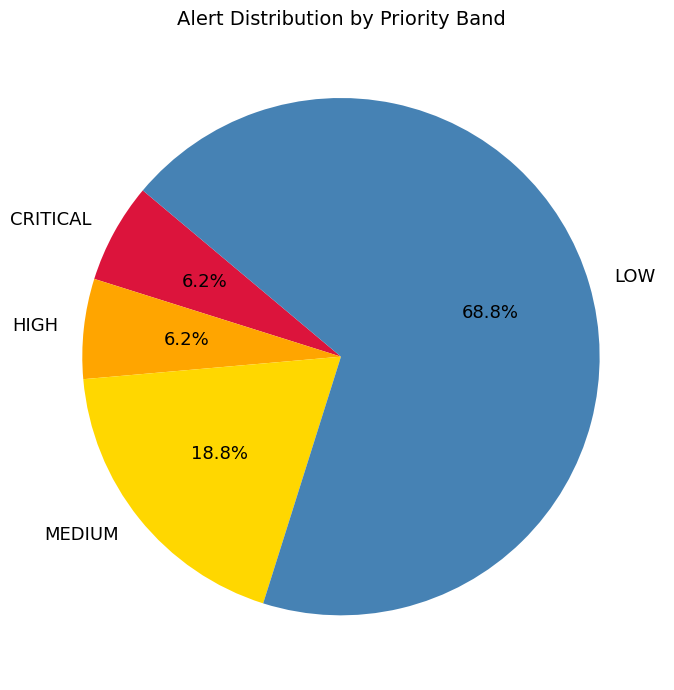

Saved priority_bands_pie.png


In [5]:
# Visual 5: Priority band pie chart
band_counts = queue["priority"].value_counts().reindex(["CRITICAL", "HIGH", "MEDIUM", "LOW"])

colors = ["crimson", "orange", "gold", "steelblue"]
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(band_counts, labels=band_counts.index, colors=colors,
       autopct="%1.1f%%", startangle=140,
       textprops={"fontsize": 13})
ax.set_title("Alert Distribution by Priority Band", fontsize=14)
plt.tight_layout()
plt.savefig("priority_bands_pie.png", dpi=150)
plt.show()
print("Saved priority_bands_pie.png")

## Section 5: Controlled Scenario and Sensitivity Evaluation

The original homelab dataset contained limited variation in asset criticality
and native ATT&CK mappings. A controlled sensitivity analysis was therefore
performed using copies of genuine Wazuh alerts.

The original alert fields were preserved. Simulated values were stored in
separate fields and clearly marked. The simulated records were used only to
examine how changes in likelihood, affected-asset criticality and ATT&CK
context influenced the calculated score and queue position.

The simulated affected-asset addresses were not collected from Wazuh.
Higher rule levels represent hypothetical specific or correlated Wazuh
detections. ATT&CK enrichment values were obtained from the documented
Atomic Red Team techniques.

This analysis demonstrates the behaviour of the formula when contextual
inputs vary. It does not represent additional genuine detections and does
not evaluate attack-detection accuracy.

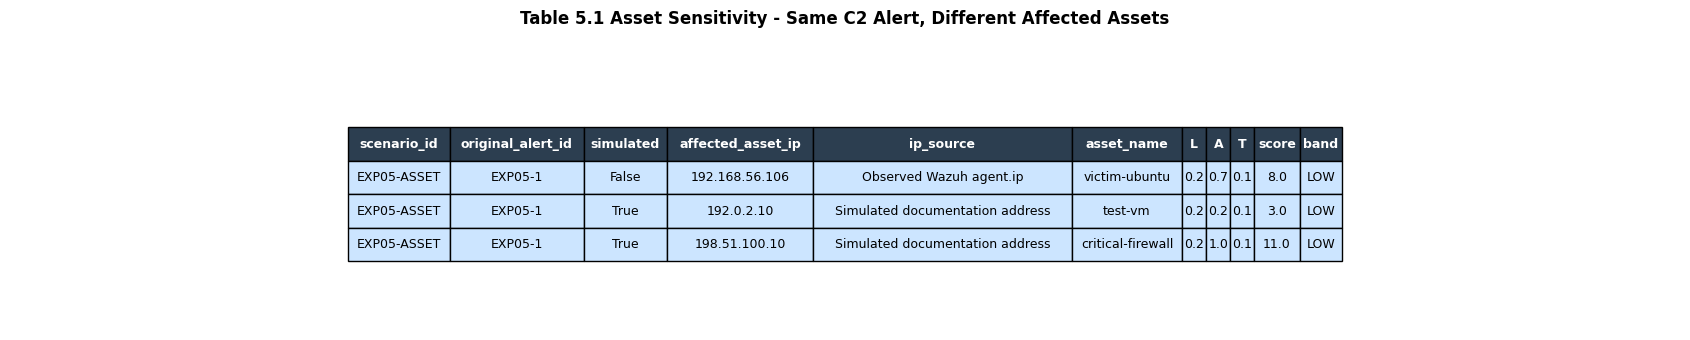

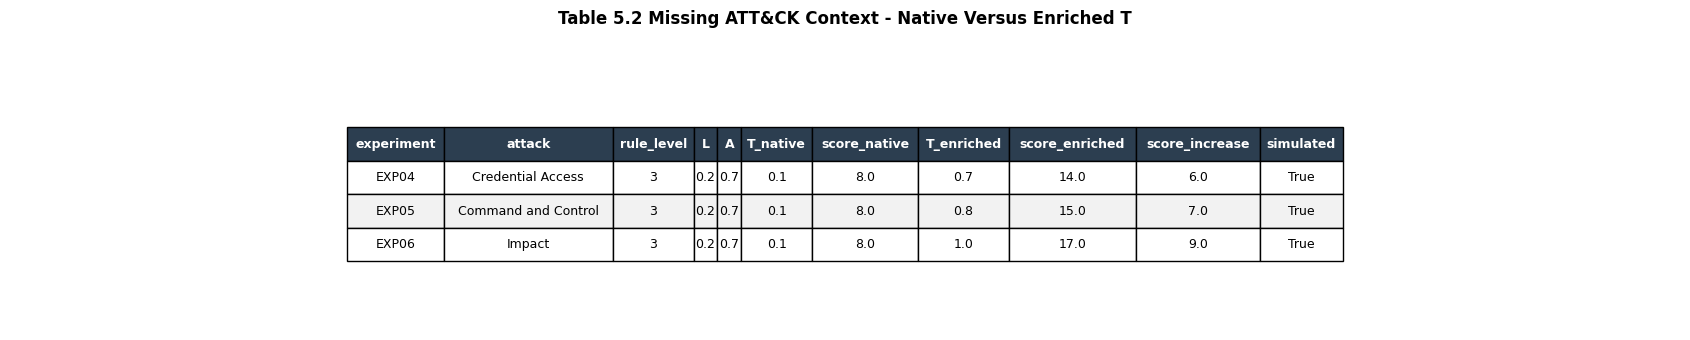

In [6]:
# ============================================================
# SECTION 5 SETUP
# ============================================================

A_VICTIM = 0.70

BAND_COLORS = {
    "CRITICAL": "#ffcccc",
    "HIGH": "#ffe5cc",
    "MEDIUM": "#ffffcc",
    "LOW": "#cce5ff"
}

exp_files = {
    "EXP01": ("EXP01.csv", "Discovery", "T1057"),
    "EXP02": ("EXP02.csv", "Persistence", "T1136.001"),
    "EXP03": ("EXP03.csv", "Privilege Escalation", "T1548.003"),
    "EXP04": ("EXP04new.csv", "Credential Access", "T1003.008"),
    "EXP05": ("EXP05.csv", "Command and Control", "T1071.001"),
    "EXP06": ("EXP06.csv", "Impact", "T1486")
}


def styled_table(
    df,
    title,
    band_col=None,
    figsize=(14, 4),
    fname=None
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=df.values.tolist(),
        colLabels=df.columns.tolist(),
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)
    table.auto_set_column_width(
        col=list(range(len(df.columns)))
    )

    for column in range(len(df.columns)):
        table[0, column].set_facecolor("#2c3e50")
        table[0, column].set_text_props(
            color="white",
            fontweight="bold"
        )

    for row_number in range(1, len(df) + 1):

        if band_col:
            row_band = str(
                df.iloc[row_number - 1][band_col]
            )

            row_colour = BAND_COLORS.get(
                row_band,
                "white"
            )
        else:
            row_colour = (
                "#f2f2f2"
                if row_number % 2 == 0
                else "white"
            )

        for column in range(len(df.columns)):
            table[row_number, column].set_facecolor(
                row_colour
            )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold",
        pad=25
    )

    plt.tight_layout()

    if fname:
        plt.savefig(
            fname,
            dpi=150,
            bbox_inches="tight"
        )

    plt.show()


# ------------------------------------------------------------
# AFFECTED-ASSET SCENARIOS
# ------------------------------------------------------------

asset_scenarios = [
    {
        "asset_name": "victim-ubuntu",
        "affected_asset_ip": "192.168.56.106",
        "A": 0.70,
        "simulated": False,
        "ip_source": "Observed Wazuh agent.ip"
    },
    {
        "asset_name": "test-vm",
        "affected_asset_ip": "192.0.2.10",
        "A": 0.20,
        "simulated": True,
        "ip_source": "Simulated documentation address"
    },
    {
        "asset_name": "critical-firewall",
        "affected_asset_ip": "198.51.100.10",
        "A": 1.00,
        "simulated": True,
        "ip_source": "Simulated documentation address"
    }
]


# ------------------------------------------------------------
# TABLE 5.1 — CHANGE A ONLY
# ------------------------------------------------------------

c2_alert = load_wazuh_csv("EXP05.csv").iloc[0]

L_c2 = score_L(c2_alert["rule.level"])
T_c2 = tactic_from_alert(c2_alert)

asset_rows = []

for asset in asset_scenarios:

    score = composite_score(
        L_c2,
        asset["A"],
        T_c2
    )

    asset_rows.append({
        "scenario_id": "EXP05-ASSET",
        "original_alert_id": "EXP05-1",
        "simulated": asset["simulated"],
        "affected_asset_ip":
            asset["affected_asset_ip"],
        "ip_source": asset["ip_source"],
        "asset_name": asset["asset_name"],
        "L": L_c2,
        "A": asset["A"],
        "T": T_c2,
        "score": score,
        "band": band(score)
    })

asset_df = pd.DataFrame(asset_rows)

styled_table(
    asset_df,
    "Table 5.1 Asset Sensitivity - Same C2 Alert, Different Affected Assets",
    band_col="band",
    figsize=(17, 3.5),
    fname="scenario_asset.png"
)


# ------------------------------------------------------------
# TABLE 5.2 — CHANGE T ONLY
# ------------------------------------------------------------

missing_context_rows = []

for experiment, intended_tactic in [
    ("EXP04", "Credential Access"),
    ("EXP05", "Command and Control"),
    ("EXP06", "Impact")
]:

    alerts = load_wazuh_csv(
        exp_files[experiment][0]
    )

    unmapped_alerts = alerts[
        alerts.apply(
            lambda row:
                tactic_from_alert(row) == DEFAULT_T,
            axis=1
        )
    ]

    representative_alert = unmapped_alerts.iloc[0]

    L_value = score_L(
        representative_alert["rule.level"]
    )

    native_score = composite_score(
        L_value,
        A_VICTIM,
        DEFAULT_T
    )

    enriched_T = tactic_T[intended_tactic]

    enriched_score = composite_score(
        L_value,
        A_VICTIM,
        enriched_T
    )

    missing_context_rows.append({
        "experiment": experiment,
        "attack": intended_tactic,
        "rule_level":
            representative_alert["rule.level"],
        "L": L_value,
        "A": A_VICTIM,
        "T_native": DEFAULT_T,
        "score_native": native_score,
        "T_enriched": enriched_T,
        "score_enriched": enriched_score,
        "score_increase":
            round(enriched_score - native_score, 2),
        "simulated": True
    })

missing_df = pd.DataFrame(
    missing_context_rows
)

styled_table(
    missing_df,
    "Table 5.2 Missing ATT&CK Context - Native Versus Enriched T",
    figsize=(17, 3.5),
    fname="scenario_missing_context.png"
)

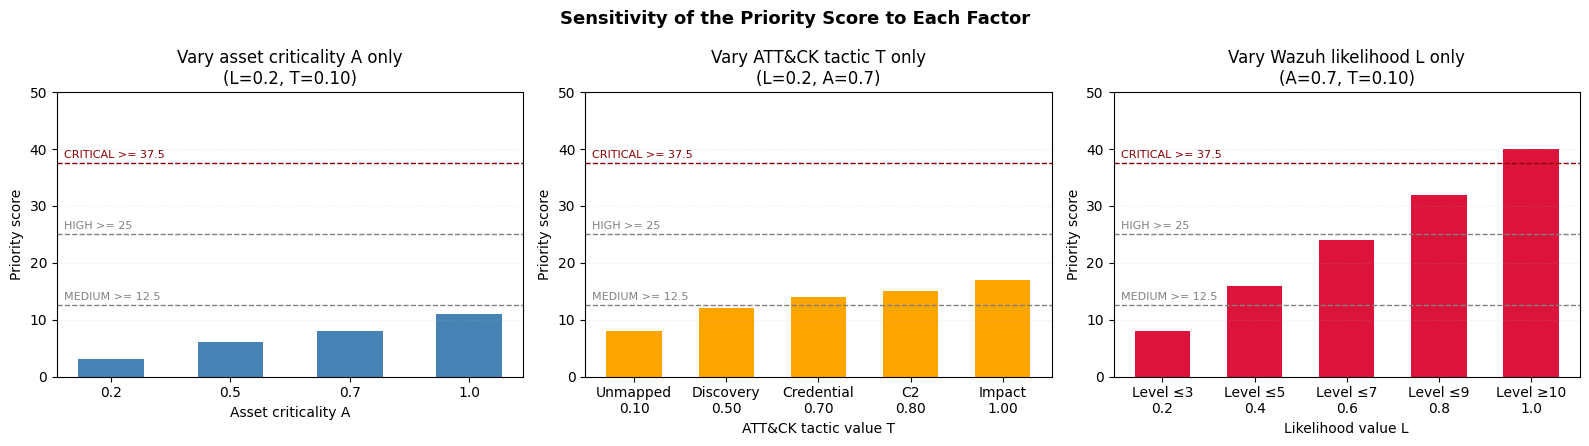

Saved scenario_sensitivity.png


In [7]:
# Figure 5.1: One-factor-at-a-time sensitivity analysis
# Change one input while keeping the other two constant.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Change asset criticality A only
A_values = [0.2, 0.5, 0.7, 1.0]
A_scores = [
    composite_score(0.2, A, 0.10)
    for A in A_values
]

axes[0].bar(
    [str(A) for A in A_values],
    A_scores,
    color="steelblue",
    width=0.55
)

axes[0].set_title(
    "Vary asset criticality A only\n"
    "(L=0.2, T=0.10)"
)
axes[0].set_xlabel("Asset criticality A")
axes[0].set_ylabel("Priority score")
axes[0].set_ylim(0, 50)


# 2. Change ATT&CK tactic T only
T_values = [0.10, 0.50, 0.70, 0.80, 1.00]
T_labels = [
    "Unmapped\n0.10",
    "Discovery\n0.50",
    "Credential\n0.70",
    "C2\n0.80",
    "Impact\n1.00"
]

T_scores = [
    composite_score(0.2, 0.7, T)
    for T in T_values
]

axes[1].bar(
    T_labels,
    T_scores,
    color="orange",
    width=0.60
)

axes[1].set_title(
    "Vary ATT&CK tactic T only\n"
    "(L=0.2, A=0.7)"
)
axes[1].set_xlabel("ATT&CK tactic value T")
axes[1].set_ylabel("Priority score")
axes[1].set_ylim(0, 50)


# 3. Change Wazuh likelihood L only
L_values = [0.2, 0.4, 0.6, 0.8, 1.0]
L_labels = [
    "Level ≤3\n0.2",
    "Level ≤5\n0.4",
    "Level ≤7\n0.6",
    "Level ≤9\n0.8",
    "Level ≥10\n1.0"
]

L_scores = [
    composite_score(L, 0.7, 0.10)
    for L in L_values
]

axes[2].bar(
    L_labels,
    L_scores,
    color="crimson",
    width=0.60
)

axes[2].set_title(
    "Vary Wazuh likelihood L only\n"
    "(A=0.7, T=0.10)"
)
axes[2].set_xlabel("Likelihood value L")
axes[2].set_ylabel("Priority score")
axes[2].set_ylim(0, 50)


# Add priority-band reference lines; labels placed at DATA y-coordinates
for ax in axes:
    tr = ax.get_yaxis_transform()  # x in axes fraction, y in data coords
    for yv, txt, col in [(37.5, "CRITICAL >= 37.5", "darkred"),
                         (25.0, "HIGH >= 25", "gray"),
                         (12.5, "MEDIUM >= 12.5", "gray")]:
        ax.axhline(yv, color=col, linestyle="--", linewidth=1)
        ax.text(0.015, yv + 0.6, txt, transform=tr, fontsize=8, color=col, va="bottom", ha="left")
    ax.grid(axis="y", linestyle=":", alpha=0.25)


fig.suptitle(
    "Sensitivity of the Priority Score to Each Factor",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "scenario_sensitivity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved scenario_sensitivity.png")

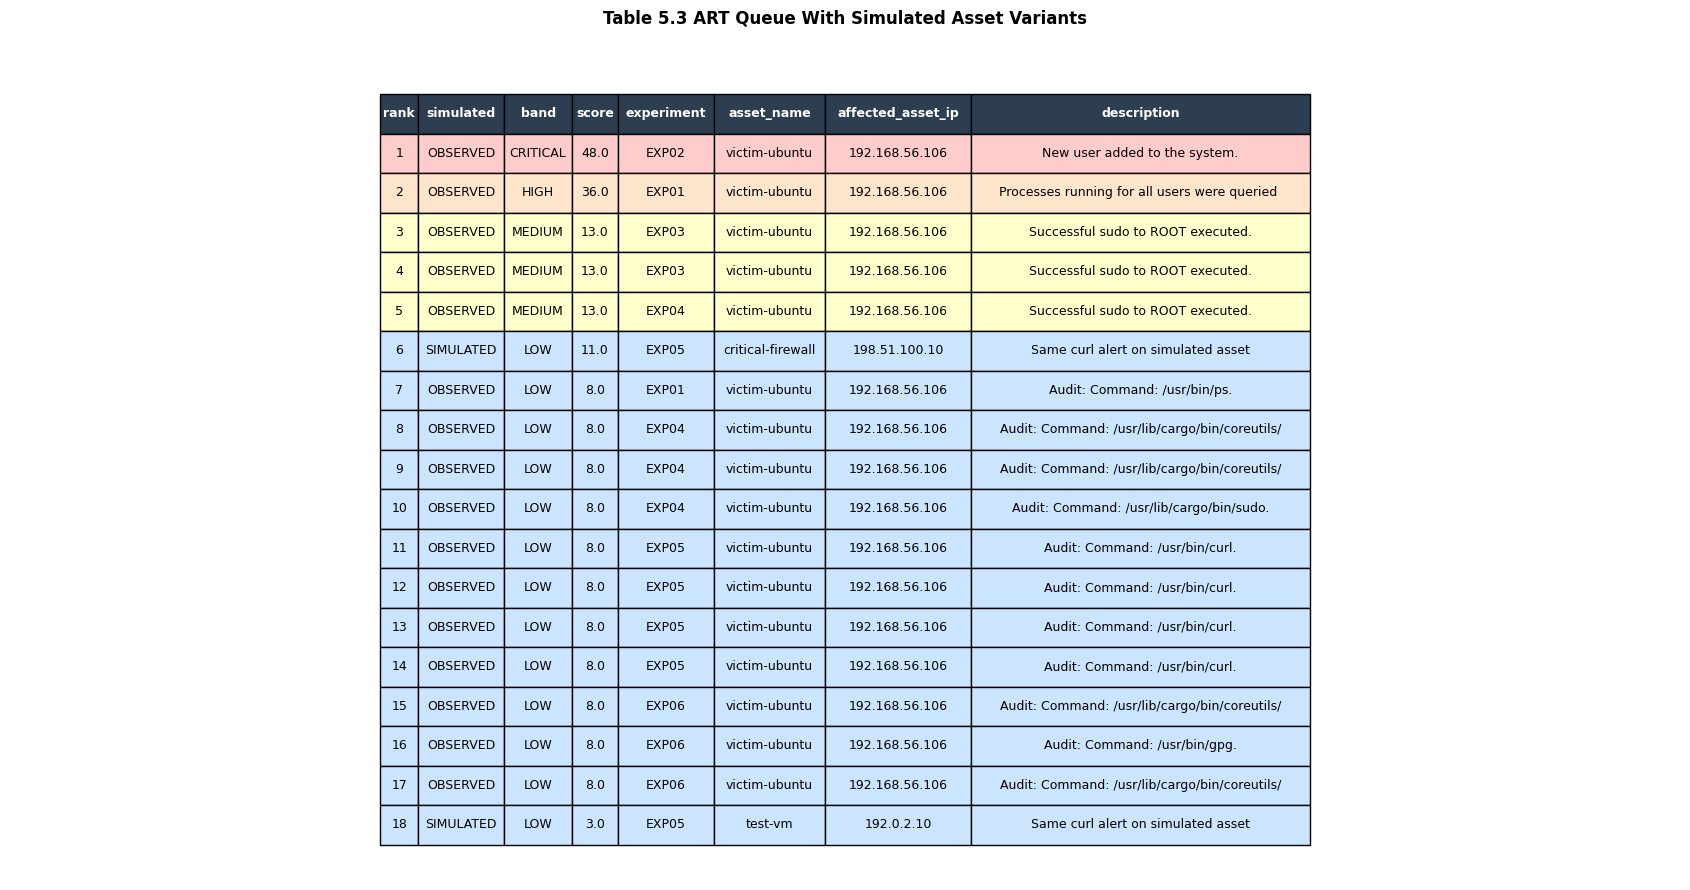

Saved Section 5 controlled outputs.


In [8]:
# ============================================================
# TABLE 5.3 — EFFECT OF ASSET CRITICALITY ON QUEUE POSITION
# ============================================================

base_alerts = []

for experiment, (
    file_path,
    intended_tactic,
    technique
) in exp_files.items():

    alerts = load_wazuh_csv(file_path)

    for alert_number, alert in alerts.iterrows():

        L_value = score_L(alert["rule.level"])
        T_value = tactic_from_alert(alert)

        score = composite_score(
            L_value,
            A_VICTIM,
            T_value
        )

        base_alerts.append({
            "alert_id":
                f"{experiment}-{alert_number + 1}",
            "experiment": experiment,
            "asset_name": "victim-ubuntu",
            "affected_asset_ip":
                str(alert.get("agent.ip", "")),
            "simulated": False,
            "description":
                str(alert["rule.description"])[:45],
            "score": score,
            "band": band(score)
        })

base_queue = pd.DataFrame(base_alerts)

simulated_variants = []

for asset in asset_scenarios:

    if not asset["simulated"]:
        continue

    score = composite_score(
        L_c2,
        asset["A"],
        T_c2
    )

    simulated_variants.append({
        "alert_id":
            f"SIM-C2-{asset['asset_name']}",
        "experiment": "EXP05",
        "asset_name": asset["asset_name"],
        "affected_asset_ip":
            asset["affected_asset_ip"],
        "simulated": True,
        "description":
            "Same curl alert on simulated asset",
        "score": score,
        "band": band(score)
    })

combined_queue = pd.concat(
    [
        base_queue,
        pd.DataFrame(simulated_variants)
    ],
    ignore_index=True
)

combined_queue = combined_queue.sort_values(
    "score",
    ascending=False,
    kind="stable"
).reset_index(drop=True)

combined_queue["rank"] = (
    combined_queue.index + 1
)

queue_display = combined_queue[
    [
        "rank",
        "simulated",
        "band",
        "score",
        "experiment",
        "asset_name",
        "affected_asset_ip",
        "description"
    ]
].copy()

queue_display["simulated"] = (
    queue_display["simulated"].map({
        True: "SIMULATED",
        False: "OBSERVED"
    })
)

styled_table(
    queue_display,
    "Table 5.3 ART Queue With Simulated Asset Variants",
    band_col="band",
    figsize=(17, 9),
    fname="scenario_queue_ranks.png"
)

asset_df.to_csv(
    "controlled_asset_scenarios.csv",
    index=False
)

missing_df.to_csv(
    "controlled_tactic_scenarios.csv",
    index=False
)

combined_queue.to_csv(
    "controlled_queue_ranks.csv",
    index=False
)

print("Saved Section 5 controlled outputs.")

### Section 5.4: Context-Enriched SOC Use Cases
One representative alert was selected from each Atomic Red Team experiment. 
The observed score uses the information supplied by Wazuh.

For the context-enriched score, the original Wazuh likelihood value was 
preserved. Only affected-asset criticality and the documented ATT&CK tactic 
were added or changed. These values are controlled assumptions and do not 
represent additional Wazuh detections.

This evaluation demonstrates how contextual enrichment changes priority while 
also showing that low Wazuh severity limits the maximum score produced by the 
multiplicative formula.

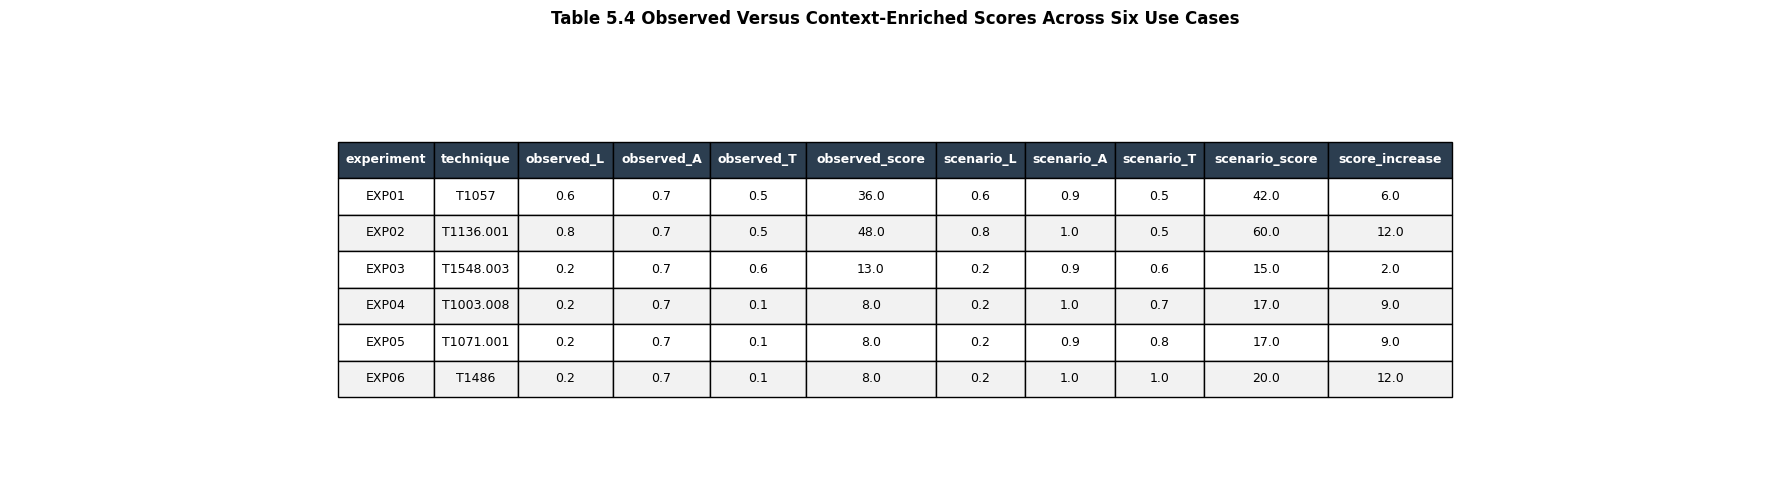

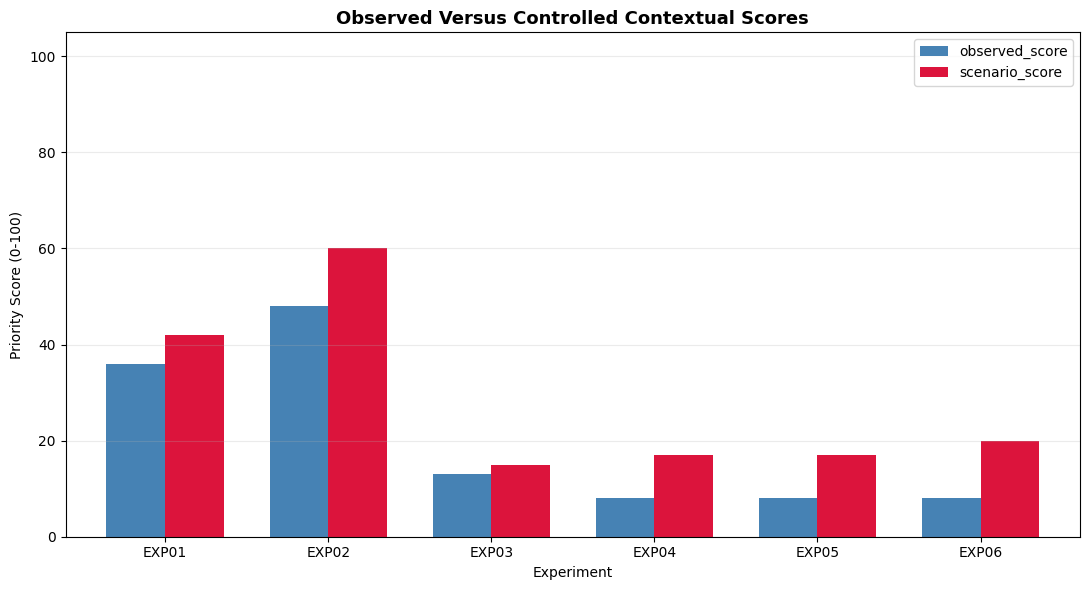

Saved six controlled SOC use cases.


In [9]:
# ============================================================
# TABLE 5.4 — SIX CONTEXT-ENRICHED SOC USE CASES
# ============================================================

soc_use_cases = [
    {
        "experiment": "EXP01",
        "technique": "T1057",
        "use_case":
            "Process discovery on production database server",
        "observed_rule_level": 6,
        "observed_A": 0.70,
        "scenario_A": 0.90,
        "observed_T": 0.50,
        "scenario_T": 0.50
    },
    {
        "experiment": "EXP02",
        "technique": "T1136.001",
        "use_case":
            "Unapproved account created on identity server",
        "observed_rule_level": 8,
        "observed_A": 0.70,
        "scenario_A": 1.00,
        "observed_T": 0.50,
        "scenario_T": 0.50
    },
    {
        "experiment": "EXP03",
        "technique": "T1548.003",
        "use_case":
            "Unexpected sudoers access on bastion server",
        "observed_rule_level": 3,
        "observed_A": 0.70,
        "scenario_A": 0.90,
        "observed_T": 0.60,
        "scenario_T": 0.60
    },
    {
        "experiment": "EXP04",
        "technique": "T1003.008",
        "use_case":
            "Unauthorised shadow-file access on identity server",
        "observed_rule_level": 3,
        "observed_A": 0.70,
        "scenario_A": 1.00,
        "observed_T": 0.10,
        "scenario_T": 0.70
    },
    {
        "experiment": "EXP05",
        "technique": "T1071.001",
        "use_case":
            "Unusual web traffic from production server",
        "observed_rule_level": 3,
        "observed_A": 0.70,
        "scenario_A": 0.90,
        "observed_T": 0.10,
        "scenario_T": 0.80
    },
    {
        "experiment": "EXP06",
        "technique": "T1486",
        "use_case":
            "Unexpected encryption on production file server",
        "observed_rule_level": 3,
        "observed_A": 0.70,
        "scenario_A": 1.00,
        "observed_T": 0.10,
        "scenario_T": 1.00
    }
]

use_case_df = pd.DataFrame(soc_use_cases)

use_case_df["observed_L"] = (
    use_case_df["observed_rule_level"].apply(
        score_L
    )
)

# Keep Wazuh likelihood unchanged.
# Only asset criticality and ATT&CK context are enriched.
use_case_df["scenario_L"] = use_case_df["observed_L"]
use_case_df["observed_score"] = (
    use_case_df.apply(
        lambda row: composite_score(
            row["observed_L"],
            row["observed_A"],
            row["observed_T"]
        ),
        axis=1
    )
)

use_case_df["scenario_score"] = (
    use_case_df.apply(
        lambda row: composite_score(
            row["scenario_L"],
            row["scenario_A"],
            row["scenario_T"]
        ),
        axis=1
    )
)

use_case_df["score_increase"] = (
    use_case_df["scenario_score"]
    - use_case_df["observed_score"]
).round(2)

use_case_df["observed_priority"] = (
    use_case_df["observed_score"].apply(band)
)

use_case_df["scenario_priority"] = (
    use_case_df["scenario_score"].apply(band)
)

use_case_df["simulated"] = True

use_case_display = use_case_df[
    [
        "experiment",
        "technique",
        "observed_L",
        "observed_A",
        "observed_T",
        "observed_score",
        "scenario_L",
        "scenario_A",
        "scenario_T",
        "scenario_score",
        "score_increase"
    ]
]

styled_table(
    use_case_display,
   "Table 5.4 Observed Versus Context-Enriched Scores Across Six Use Cases",
    figsize=(18, 5),
    fname="six_use_case_scores.png"
)

# Chart
chart_data = use_case_df.set_index(
    "experiment"
)[
    [
        "observed_score",
        "scenario_score"
    ]
]

ax = chart_data.plot(
    kind="bar",
    figsize=(11, 6),
    color=["steelblue", "crimson"],
    width=0.72
)

ax.set_title(
    "Observed Versus Controlled Contextual Scores",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Experiment")
ax.set_ylabel("Priority Score (0-100)")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "six_use_case_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

use_case_df.to_csv(
    "six_controlled_soc_use_cases.csv",
    index=False
)

print("Saved six controlled SOC use cases.")